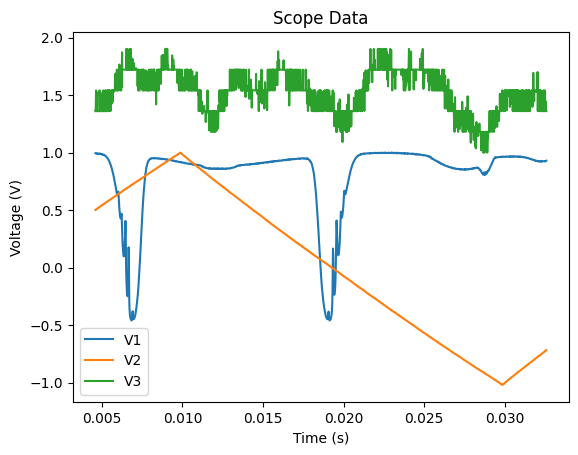

In [1]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt



data = pd.read_csv("scope_7.csv")
data["V2"] = data["V2"]/data["V2"].max()
data["V3"] = data["V3"]/data["V3"].max()
data["V1"] = data["V1"]/data["V1"].max()

plt.plot(data["T"], data["V1"], label="V1")
plt.plot(data["T"], data["V2"], label="V2")

plt.plot(data["T"], data["V3"], label="V3")
# plt.plot(data["T"], data["V4"], label="V4")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Scope Data")
plt.legend()
plt.show()


Fabry-Perot пики
965     0.016110
1618    0.025252
Name: T_shift, dtype: float64

GHz per T
437.5410194705755
MHz per T
437541.0194705755

Пики насыщенного
1033    0.019662
1053    0.019942
1069    0.020166
1088    0.020432
1103    0.020642
Name: T_shift, dtype: float64

Расстояния MHz
[122.51148545  98.00918836 116.38591118  91.88361409]
Растония между уровнями
220.5206738131705 208.26952526799425


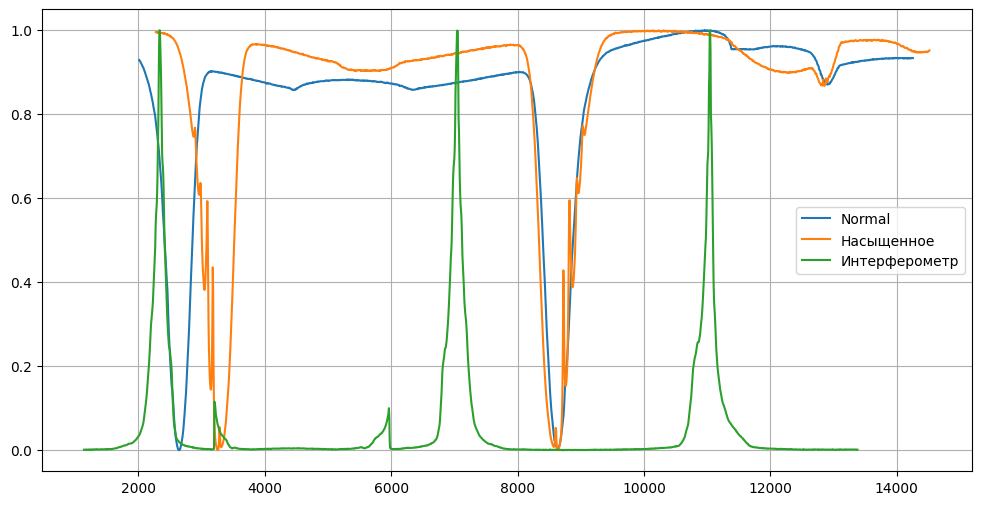

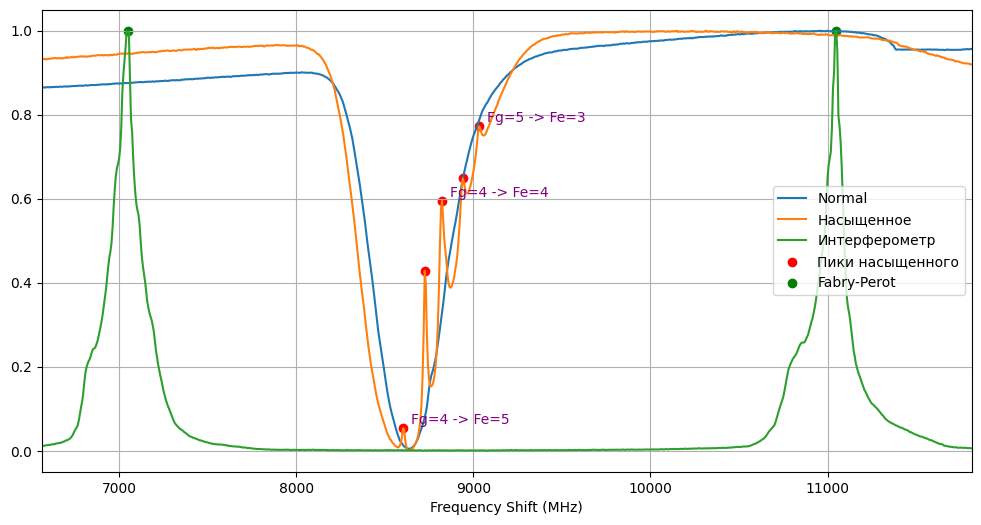

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

# =========================
# Загрузка
# =========================

data_norm = pd.read_csv("scope_8.csv")
data_nas = pd.read_csv("scope_7.csv")
data_febri = pd.read_csv("scope_10.csv")

# =========================
# СДВИГИ
# =========================

shift_norm = 0.0
shift_nas = 0.0006
shift_febri = -0.002

data_norm["T_shift"] = data_norm["T"] + shift_norm
data_nas["T_shift"] = data_nas["T"] + shift_nas
data_febri["T_shift"] = data_febri["T"] + shift_febri



# =========================
# НОРМИРОВКА
# =========================

data_norm["V_norm"] = (data_norm["V1"] - data_norm["V1"].min()) / (data_norm["V1"].max() - data_norm["V1"].min())
data_nas["V_norm"] = (data_nas["V1"] - data_nas["V1"].min()) / (data_nas["V1"].max() - data_nas["V1"].min())
data_febri["V_norm"] = (data_febri["V3"] - data_febri["V3"].min()) / (data_febri["V3"].max() - data_febri["V3"].min())

# =========================
# ОБЩИЙ СРЕЗ
# =========================

T_min = 0.015
T_max = 0.027

# УЗКИЙ СРЕЗ ДЛЯ НАСЫЩЕННОГО
T_nas_min = 0.017
T_nas_max = 0.025

data_norm_cut = data_norm[(data_norm["T_shift"] > T_min) & (data_norm["T_shift"] < T_max)]
data_nas_cut = data_nas[(data_nas["T_shift"] > T_nas_min) & (data_nas["T_shift"] < T_nas_max)]
data_febri_cut = data_febri[(data_febri["T_shift"] > T_min) & (data_febri["T_shift"] < T_max)]

# =========================
# FABRY PEROT
# =========================

peaks_febri, props = find_peaks(
    data_febri_cut["V_norm"],
    prominence=0.1,
    distance=200
)

# два самых больших
top2 = np.argsort(props["prominences"])[-2:]
peaks_febri = peaks_febri[top2]

febri_peaks = data_febri_cut.iloc[peaks_febri]
febri_peaks = febri_peaks.sort_values("T_shift")

GHz_per_T = 4 / (febri_peaks["T_shift"].iloc[1] - febri_peaks["T_shift"].iloc[0])
MHz_per_T = GHz_per_T * 1000

print("Fabry-Perot пики")
print(febri_peaks["T_shift"])

print("\nGHz per T")
print(GHz_per_T)
print("MHz per T")
print(MHz_per_T)

# =========================
# НАСЫЩЕННОЕ ПОГЛОЩЕНИЕ
# =========================


data_nas_peaks = data_nas[
    (data_nas["T_shift"] > T_nas_min) &
    (data_nas["T_shift"] < T_nas_max)
]

peaks_nas, props_nas = find_peaks(
    data_nas_cut["V_norm"],
    prominence=0.02,
    distance=6
)

nas_peaks = data_nas_cut.iloc[peaks_nas]

distances_T = np.diff(nas_peaks["T_shift"])
distances_MHz = distances_T * MHz_per_T

print("\nПики насыщенного")
print(nas_peaks["T_shift"])

print("\nРасстояния MHz")
print(distances_MHz)
print("Растония между уровнями")
print(distances_MHz[0] + distances_MHz[1], distances_MHz[2]+distances_MHz[3])

# =========================
# ОСНОВНОЙ ГРАФИК
# =========================

plt.figure(figsize=(12,6))

plt.plot(data_norm["T_shift"] * MHz_per_T, data_norm["V_norm"], label="Normal")
plt.plot(data_nas["T_shift"] * MHz_per_T, data_nas["V_norm"], label="Насыщенное")
plt.plot(data_febri["T_shift"] * MHz_per_T, data_febri["V_norm"], label="Интерферометр")

plt.legend()
plt.grid()

# =========================
# ZOOM ГРАФИК
# =========================

plt.figure(figsize=(12,6))

plt.plot(data_norm["T_shift"] * MHz_per_T, data_norm["V_norm"], label="Normal")
plt.plot(data_nas["T_shift"] * MHz_per_T, data_nas["V_norm"], label="Насыщенное")
plt.plot(data_febri["T_shift"] * MHz_per_T, data_febri["V_norm"], label="Интерферометр")

# все пики на zoom
plt.scatter(
    nas_peaks["T_shift"] * MHz_per_T,
    nas_peaks["V_norm"],
    color="red",
    label="Пики насыщенного",
 )
labels = ['Fg=4 -> Fe=5', 'Fg=4 -> Fe=4', 'Fg=5 -> Fe=3']
for i, idx in enumerate([0, 2, 4]):
    plt.annotate(labels[i], xy=(nas_peaks.iloc[idx]["T_shift"] * MHz_per_T, nas_peaks.iloc[idx]["V_norm"]), 
                 xytext=(nas_peaks.iloc[idx]["T_shift"] * MHz_per_T + 0.0001 * MHz_per_T, nas_peaks.iloc[idx]["V_norm"] + 0.01),
                 fontsize=10, color='Purple')

plt.scatter(
    febri_peaks["T_shift"] * MHz_per_T,
    febri_peaks["V_norm"],
    color="green",
    label="Fabry-Perot",
 )   

plt.xlim(0.015 * MHz_per_T, 0.027 * MHz_per_T)

plt.legend()
plt.grid()
plt.xlabel("Frequency Shift (MHz)")
plt.savefig("cooling_cs.png", dpi=300)
plt.show()


Gaussian fit:
[ 8.67817010e-01 -8.55590603e-01  8.57936702e+03  2.37815788e+02]


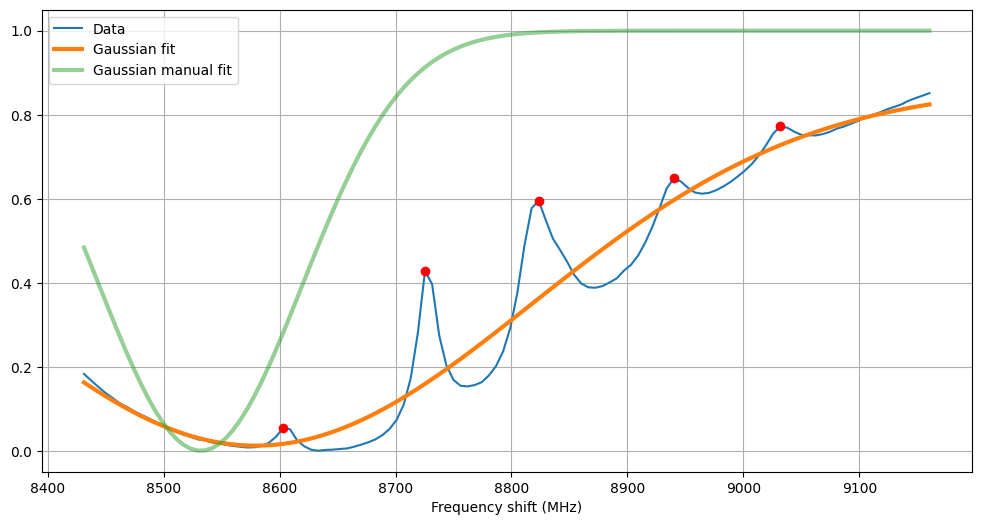

In [ ]:
# ============================================================
#                     ДАННЫЕ ДЛЯ FIT
# ============================================================
# trim data_nas_cut to a tight window around the detected peaks
margin = 0.004
t_peaks = nas_peaks["T_shift"].values
tmin = t_peaks.min() - 0.0004
tmax = t_peaks.max() + 0.0003

data_nas_cut = (
    data_nas_cut
    .dropna(subset=["T_shift", "V_norm"])
    .loc[lambda df: (df["T_shift"] >= tmin) & (df["T_shift"] <= tmax)]
    .reset_index(drop=True)
 )

# convert x to MHz for fitting
xdata = data_nas_cut["T_shift"].values * MHz_per_T
ydata = data_nas_cut["V_norm"].values

peak_positions = nas_peaks["T_shift"].values[:5] * MHz_per_T

# ============================================================
#                     МОДЕЛИ
# ============================================================

def gaussian(x, offset, amplitude, center, sigma):
    return offset + amplitude * np.exp(
        -(x - center)**2 / (2 * sigma**2)
    )


def lorentzian(x, amplitude, center, gamma):
    return amplitude * gamma**2 / (
        (x - center)**2 + gamma**2
    )

def full_model(
    x,
    offset,
    gauss_amp,
    gauss_center,
    gauss_sigma,

    A1, x1, g1,
    A2, x2, g2,
    A3, x3, g3,
    A4, x4, g4,
    A5, x5, g5,
 ):

    envelope = gaussian(
        x,
        offset,
        gauss_amp,
        gauss_center,
        gauss_sigma
    )

    dips = (
        lorentzian(x, A1, x1, g1)
        + lorentzian(x, A2, x2, g2)
        + lorentzian(x, A3, x3, g3)
        + lorentzian(x, A4, x4, g4)
        + lorentzian(x, A5, x5, g5)
    )

    return offset + gauss_amp * np.exp(
        -(x - gauss_center)**2 / (2 * gauss_sigma**2)) * (1 - dips)

# ============================================================
#                FIT ТОЛЬКО ГАУССИАНЫ
# ============================================================

p0_gauss = [1,-1,0.0195 * MHz_per_T,0.0002 * MHz_per_T]

params_gauss, _ = curve_fit(
    gaussian,
    xdata,
    ydata,
    p0=p0_gauss
 )

print("\nGaussian fit:")
print(params_gauss)

# ============================================================
#                  ГРАФИК ГАУССИАНЫ
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(xdata, ydata, label="Data")
plt.plot(
    xdata,
    gaussian(xdata, *params_gauss),
    linewidth=3,
    label="Gaussian fit"
 )
plt.plot(
    xdata,
    gaussian(xdata, *p0_gauss),
    linewidth=3,
    alpha=0.5,
    label="Gaussian manual fit"
 )
plt.scatter(
    peak_positions,
    np.interp(peak_positions, xdata, ydata),
    color="red",
    zorder=10
)

plt.grid()
plt.legend()
plt.xlabel("Frequency shift (MHz)")
plt.show()


Initial Lorentzian parameters:
Peak 1: Amplitude = 0.07, Center = 8602.931524830456, Gamma = 30
Peak 2: Amplitude = 0.2, Center = 8725.443010282217, Gamma = 30
Peak 3: Amplitude = 0.2, Center = 8823.452198643625, Gamma = 30
Peak 4: Amplitude = 0.3, Center = 8939.838109822798, Gamma = 30
Peak 5: Amplitude = 0.1, Center = 9031.72172391162, Gamma = 30

GAUSSIAN
offset = 0.925050
amp    = -1.079095
center = 8624.82323321
sigma  = 235.25890300

LORENTZIAN DIPS

Peak 1
Amplitude = 0.150590
Center T  = 8608.74881611
Gamma     = 96.81 MHz

Peak 2
Amplitude = 0.413736
Center T  = 8727.75847916
Gamma     = -11.93 MHz
Delta = 52071.61 MHz

Peak 3
Amplitude = 0.523939
Center T  = 8824.39082110
Gamma     = 20.64 MHz
Delta = 42280.61 MHz

Peak 4
Amplitude = 0.327824
Center T  = 8940.86173890
Gamma     = 17.98 MHz
Delta = 50960.80 MHz

Peak 5
Amplitude = 0.332201
Center T  = 9031.29021444
Gamma     = -18.54 MHz
Delta = 39566.17 MHz


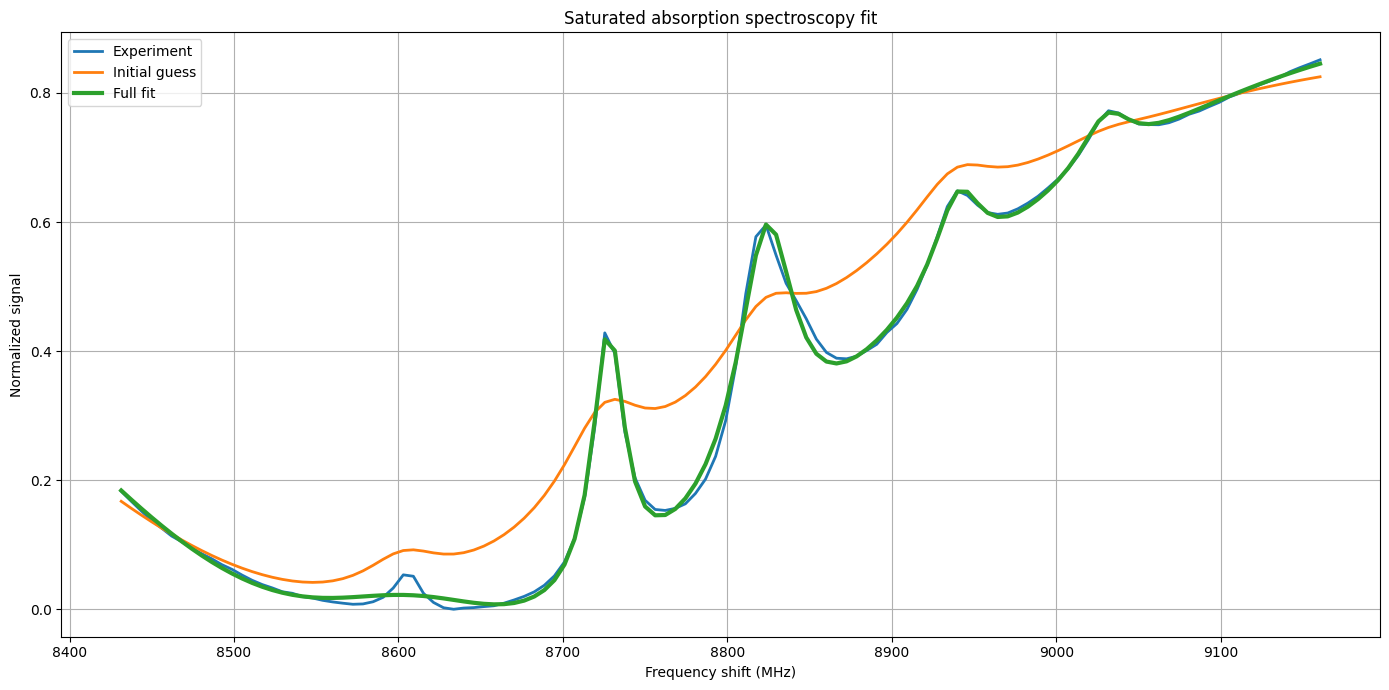

In [4]:
# ============================================================
#              РУЧНАЯ ПОДКРУТКА + FIT
# ============================================================

# ------------------------------------------------------------
# НАЧАЛЬНЫЕ ПАРАМЕТРЫ ГАУССИАНЫ
# ------------------------------------------------------------

offset      = params_gauss[0]
gauss_amp   = params_gauss[1]
gauss_ctr   = params_gauss[2]
gauss_sigma = params_gauss[3]


# ------------------------------------------------------------
# НАЧАЛЬНЫЕ ПАРАМЕТРЫ ЛОРЕНЦИАНОВ
# ------------------------------------------------------------

# format:
# [amplitude, center, gamma]

lorentz_params = [

    [0.07, peak_positions[0], 30],
    [0.2, peak_positions[1], 30],
    [0.2, peak_positions[2], 30],
    [0.3, peak_positions[3], 30],
    [0.1, peak_positions[4], 30],

]
print("\nInitial Lorentzian parameters:")
for i, (A, x0, g) in enumerate(lorentz_params):
    print(f"Peak {i+1}: Amplitude = {A}, Center = {x0}, Gamma = {g}")

# ============================================================
#            СОБИРАЕМ ВЕКТОР НАЧАЛЬНЫХ ПАРАМЕТРОВ
# ============================================================

p0 = [
    offset,
    gauss_amp,
    gauss_ctr,
    gauss_sigma
]

for pars in lorentz_params:
    p0.extend(pars)


# ============================================================
#                     ПОЛНЫЙ FIT
# ============================================================

params_fit, covariance = curve_fit(
    full_model,
    xdata,
    ydata,
    p0=p0,
    maxfev=100000
)


# ============================================================
#                 РЕЗУЛЬТАТ FIT
# ============================================================

fit_total = full_model(xdata, *params_fit)
fit_init =  full_model(xdata, *p0)

fit_envelope = gaussian(
    xdata,
    *params_fit[:4]
)


# ============================================================
#                   ПЕЧАТЬ ПАРАМЕТРОВ
# ============================================================

print("\n==============================")
print("GAUSSIAN")
print("==============================")

print(f"offset = {params_fit[0]:.6f}")
print(f"amp    = {params_fit[1]:.6f}")
print(f"center = {params_fit[2]:.8f}")
print(f"sigma  = {params_fit[3]:.8f}")

print("\n==============================")
print("LORENTZIAN DIPS")
print("==============================")

for i in range(5):

    A  = params_fit[4 + 3*i]
    x0 = params_fit[5 + 3*i]
    g  = params_fit[6 + 3*i]

    gamma_MHz = g

    print(f"\nPeak {i+1}")
    print(f"Amplitude = {A:.6f}")
    print(f"Center T  = {x0:.8f}")
    print(f"Gamma     = {gamma_MHz:.2f} MHz")

    if i > 0:

        prev_x0 = params_fit[5 + 3*(i-1)]

        delta = (x0 - prev_x0) * GHz_per_T

        print(f"Delta = {delta:.2f} MHz")


# ============================================================
#                       ГРАФИК
# ============================================================

plt.figure(figsize=(14,7))

# эксперимент
plt.plot(
    xdata,
    ydata,
    linewidth=2,
    label="Experiment"
)

plt.plot(
xdata,fit_init,
linewidth=2,label="Initial guess"
)

# итоговый fit
plt.plot(
    xdata,
    fit_total,
    linewidth=3,
    label="Full fit"
)

# # гауссова огибающая
# plt.plot(
#     xdata,
#     fit_envelope,
#     "--",
#     linewidth=2,
#     label="Gaussian envelope"
# )

# # отдельные лоренцианы
# for i in range(5):

#     A  = params_fit[4 + 3*i]
#     x0 = params_fit[5 + 3*i]
#     g  = params_fit[6 + 3*i]

#     single_peak = (
#         lorentzian(xdata, A, x0, g)
#     )

#     plt.plot(
#         xdata,
#         single_peak,
#         alpha=0.5
#     )

#     plt.axvline(
#         x0,
#         linestyle=":",
#         alpha=0.5
#     )


# ============================================================
#                     ОФОРМЛЕНИЕ
# ============================================================

plt.xlabel("Frequency shift (MHz)")
plt.ylabel("Normalized signal")

plt.title("Saturated absorption spectroscopy fit")

plt.grid()
plt.legend()

plt.tight_layout()
plt.savefig("cooling_cs_fit.png", dpi=300)
plt.show()

Fabry-Perot пики
965     0.016110
1618    0.025252
Name: T_shift, dtype: float64

MHz per T
437541.0194705755

Пики насыщенного
1034    0.019676
1053    0.019942
1068    0.020152
1088    0.020432
1103    0.020642
1188    0.021832
Name: T_shift, dtype: float64

Расстояния MHz
[116.38591118  91.88361409 122.51148545  91.88361409 520.67381317]

Расстояния между пиками поглощения
208.26952526799425 214.39509954058235

Расстояния между всеми уровнями: [116.38591118  91.88361409 122.51148545  91.88361409 520.67381317]


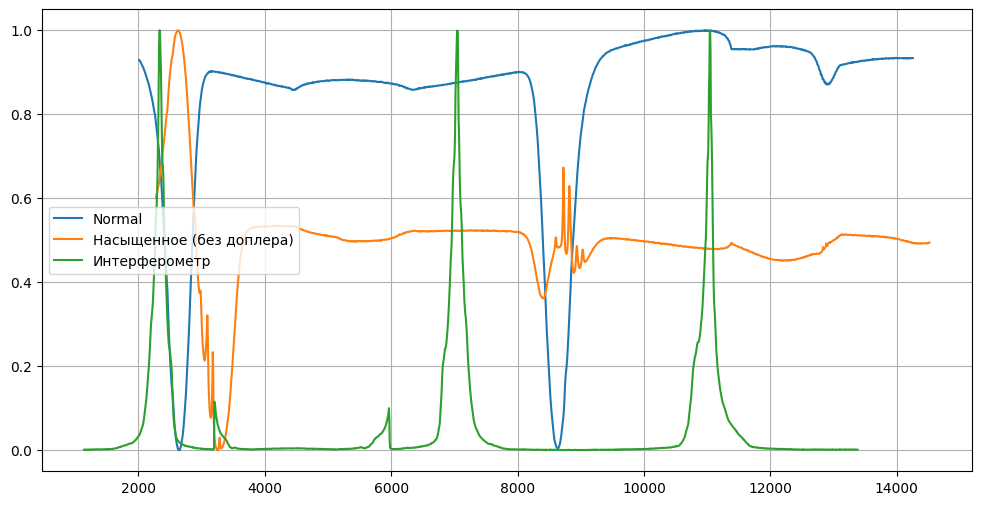

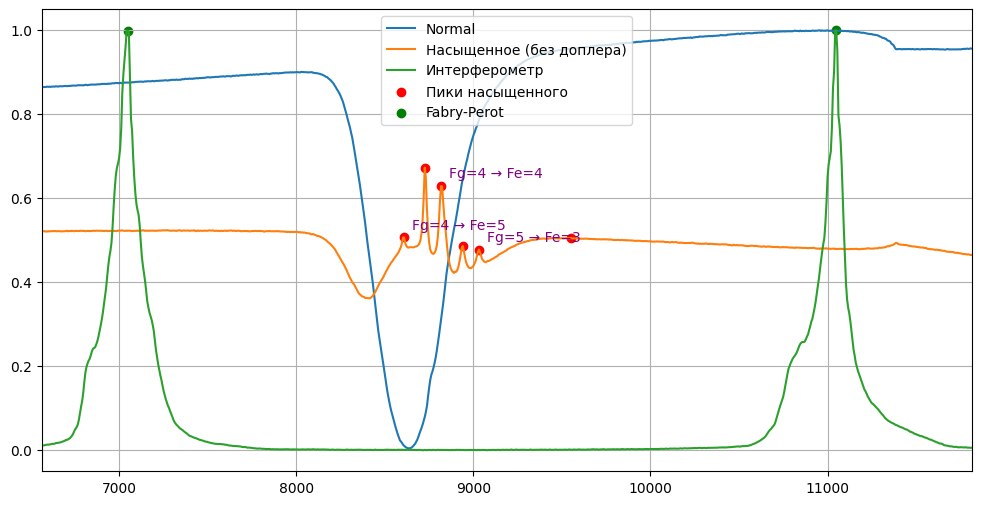

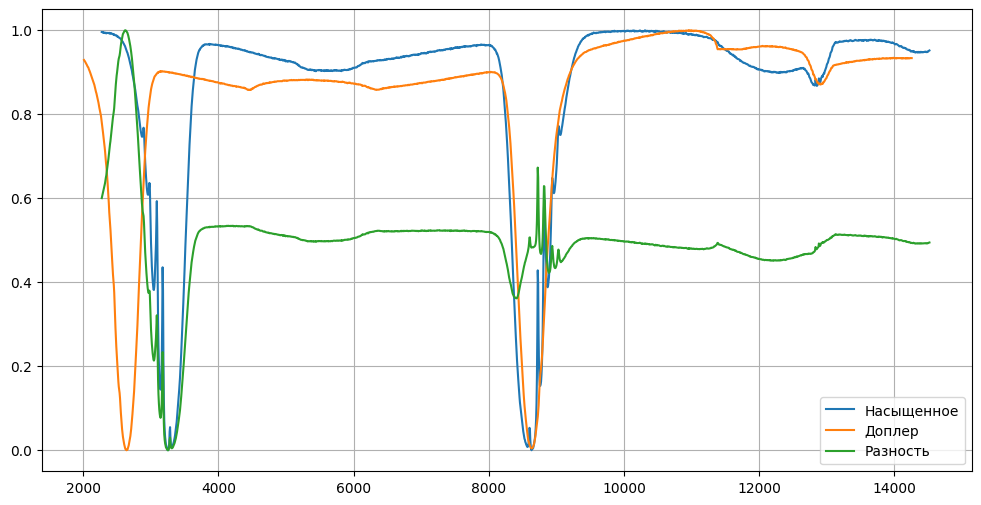

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# =========================
# Загрузка
# =========================

data_norm = pd.read_csv("scope_8.csv")
data_nas = pd.read_csv("scope_7.csv")
data_febri = pd.read_csv("scope_10.csv")

# =========================
# СДВИГИ
# =========================

shift_norm = 0.0
shift_nas = 0.0006
shift_febri = -0.002

data_norm["T_shift"] = data_norm["T"] + shift_norm
data_nas["T_shift"] = data_nas["T"] + shift_nas
data_febri["T_shift"] = data_febri["T"] + shift_febri

# =========================
# НОРМИРОВКА
# =========================

data_norm["V_norm"] = (
    (data_norm["V1"] - data_norm["V1"].min()) /
    (data_norm["V1"].max() - data_norm["V1"].min())
 )

data_nas["V_norm"] = (
    (data_nas["V1"] - data_nas["V1"].min()) /
    (data_nas["V1"].max() - data_nas["V1"].min())
 )

data_febri["V_norm"] = (
    (data_febri["V3"] - data_febri["V3"].min()) /
    (data_febri["V3"].max() - data_febri["V3"].min())
 )

# =========================
# ВЫЧИТАНИЕ ДОПЛЕРОВСКОГО ФОНА
# =========================

norm_interp = np.interp(
    data_nas["T_shift"],
    data_norm["T_shift"],
    data_norm["V_norm"]
)

data_nas["V_sub"] = data_nas["V_norm"] - norm_interp

# нормировка после вычитания
data_nas["V_sub"] = data_nas["V_sub"] - data_nas["V_sub"].min()
data_nas["V_sub"] = data_nas["V_sub"] / data_nas["V_sub"].max()

# =========================
# ДИАПАЗОНЫ
# =========================

T_min = 0.015
T_max = 0.027

T_nas_min = 0.017
T_nas_max = 0.025

data_norm_cut = data_norm[
    (data_norm["T_shift"] > T_min) &
    (data_norm["T_shift"] < T_max)
 ]

data_nas_cut = data_nas[
    (data_nas["T_shift"] > T_nas_min) &
    (data_nas["T_shift"] < T_nas_max)
 ]

data_febri_cut = data_febri[
    (data_febri["T_shift"] > T_min) &
    (data_febri["T_shift"] < T_max)
 ]

# =========================
# FABRY-PEROT
# =========================

peaks_febri, props = find_peaks(
    data_febri_cut["V_norm"],
    prominence=0.1,
    distance=200
)

top2 = np.argsort(props["prominences"])[-2:]
peaks_febri = peaks_febri[top2]

febri_peaks = data_febri_cut.iloc[peaks_febri]
febri_peaks = febri_peaks.sort_values("T_shift")

GHz_per_T = 4 / (
    febri_peaks["T_shift"].iloc[1] -
    febri_peaks["T_shift"].iloc[0]
 )
MHz_per_T = GHz_per_T * 1000

print("Fabry-Perot пики")
print(febri_peaks["T_shift"])

print("\nMHz per T")
print(MHz_per_T)

# =========================
# НАСЫЩЕННОЕ ПОГЛОЩЕНИЕ
# =========================

peaks_nas, props_nas = find_peaks(
    data_nas_cut["V_sub"],
    prominence=0.02,
    distance=6
)

nas_peaks = data_nas_cut.iloc[peaks_nas]

distances_T = np.diff(nas_peaks["T_shift"])
distances_MHz = distances_T * MHz_per_T

print("\nПики насыщенного")
print(nas_peaks["T_shift"])

print("\nРасстояния MHz")
print(distances_MHz)

print("\nРасстояния между пиками поглощения")
print(
    distances_MHz[0] + distances_MHz[1],
    distances_MHz[2] + distances_MHz[3],
 )
print(f"\nРасстояния между всеми уровнями: {distances_MHz}")

# =========================
# ОСНОВНОЙ ГРАФИК
# =========================

plt.figure(figsize=(12,6))

plt.plot(
    data_norm["T_shift"] * MHz_per_T,
    data_norm["V_norm"],
    label="Normal",
 )

plt.plot(
    data_nas["T_shift"] * MHz_per_T,
    data_nas["V_sub"],
    label="Насыщенное (без доплера)",
 )

plt.plot(
    data_febri["T_shift"] * MHz_per_T,
    data_febri["V_norm"],
    label="Интерферометр",
 )

plt.legend()
plt.grid()

# =========================
# ZOOM ГРАФИК
# =========================

plt.figure(figsize=(12,6))

plt.plot(
    data_norm["T_shift"] * MHz_per_T,
    data_norm["V_norm"],
    label="Normal",
 )

plt.plot(
    data_nas["T_shift"] * MHz_per_T,
    data_nas["V_sub"],
    label="Насыщенное (без доплера)",
 )

plt.plot(
    data_febri["T_shift"] * MHz_per_T,
    data_febri["V_norm"],
    label="Интерферометр",
 )

# пики насыщенного
plt.scatter(
    nas_peaks["T_shift"] * MHz_per_T,
    nas_peaks["V_sub"],
    color="red",
    label="Пики насыщенного",
 )

# подписи переходов
labels = [
    'Fg=4 → Fe=5',
    'Fg=4 → Fe=4',
    'Fg=5 → Fe=3'
 ]

for i, idx in enumerate([0, 2, 4]):
    plt.annotate(
        labels[i],
        xy=(
            nas_peaks.iloc[idx]["T_shift"] * MHz_per_T,
            nas_peaks.iloc[idx]["V_sub"]
        ),
        xytext=(
            nas_peaks.iloc[idx]["T_shift"] * MHz_per_T + 0.0001 * MHz_per_T,
            nas_peaks.iloc[idx]["V_sub"] + 0.02
        ),
        fontsize=10,
        color='purple',
    )

# пики Fabry-Perot
plt.scatter(
    febri_peaks["T_shift"] * MHz_per_T,
    febri_peaks["V_norm"],
    color="green",
    label="Fabry-Perot",
 )

plt.xlim(0.015 * MHz_per_T, 0.027 * MHz_per_T)

plt.legend()
plt.grid()

plt.savefig("cooling_cs_2.png", dpi=300)

# =========================
# Контрольный график (фон)
# =========================

plt.figure(figsize=(12,6))

plt.plot(
    data_nas["T_shift"] * MHz_per_T,
    data_nas["V_norm"],
    label="Насыщенное",
 )

plt.plot(
    data_norm["T_shift"] * MHz_per_T,
    data_norm["V_norm"],
    label="Доплер",
 )

plt.plot(
    data_nas["T_shift"] * MHz_per_T,
    data_nas["V_sub"],
    label="Разность",
 )

plt.legend()
plt.grid()

plt.show()